# Resolution Scoping Benchmark

This notebook measures the cost and quality of NeRF training at several image resolutions, so the Phase 2 experiment resolution is chosen from data rather than guessed (Stage 0 of `project/tutorial2_plan.md`).

It trains a compact NeRF on one scene (Lego) at resolutions 100, 200, 400, and 800, with a fixed optimizer (Adam), loss (L2), and seed. For each resolution it records per-iteration training time, peak VRAM, full-image render time, held-out PSNR/SSIM over iterations, and the wall-clock to reach a target PSNR.

Key point: NeRF training samples a fixed batch of rays per step, so per-iteration training cost is roughly resolution-independent. Resolution mainly affects convergence speed, evaluation cost, VRAM, and the quality ceiling. The headline number for the decision is therefore wall-clock to reach the target PSNR.

# 1. Setup

In [1]:
import os, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim_metric

In [2]:
# Configuration

DEVICE       = "cuda"
SCENE_DIR    = "../data/nerf_synthetic/lego"   # full nerf_synthetic Lego scene
RESOLUTIONS  = [100, 200, 400, 800]            # resolutions to benchmark
N_ITERATIONS = 20000                           # training iterations per resolution
EVAL_EVERY   = 1000                            # evaluate held-out views every N iterations
N_TEST_VIEWS = 3                               # held-out views used for evaluation
TARGET_PSNR  = 25.0                            # target quality for the time-to-target metric
RUN_COUNT    = 100                             # rough size of the Phase 2 experiment matrix

# Fixed training hyperparameters (held constant across resolutions)
N_SAMPLES   = 64
BATCH_RAYS  = 1024
LR          = 5e-4
SEED        = 0
NEAR, FAR   = 2.0, 6.0

# Data presence check
if not os.path.isdir(SCENE_DIR):
    raise FileNotFoundError(
        f"Scene not found at {SCENE_DIR}.\n"
        f"Download nerf_synthetic.zip from the NeRF authors' Google Drive "
        f"(folder 1cK3UDIJqKAAm7zyrxRYVFJ0BRMgrwhh4), unzip into ../data/ so that "
        f"{SCENE_DIR}/transforms_train.json exists."
    )
print("device:", DEVICE, "| CUDA:", torch.cuda.is_available())
print("scene :", SCENE_DIR)

device: cuda | CUDA: True
scene : ../data/nerf_synthetic/lego


# 2. Data Loading

The `nerf_synthetic` scenes are 800x800 RGBA images with transparent backgrounds. We load each split once at native resolution, composite the alpha over a white background (the standard NeRF-synthetic convention), and downscale to each benchmark resolution with area interpolation. Loading once and downscaling in memory avoids re-decoding the PNGs for every resolution.

In [3]:
def load_nerf_synthetic_split(scene_dir, split, max_views=None):
    """Load a nerf_synthetic split at native resolution.
    Returns (images [N,H,W,3] float CPU tensor, poses [N,4,4] CPU tensor, native_focal)."""
    with open(os.path.join(scene_dir, f"transforms_{split}.json")) as f:
        meta = json.load(f)
    frames = meta["frames"]
    if max_views is not None:
        frames = frames[:max_views]
    imgs, poses = [], []
    for frame in frames:
        path = os.path.join(scene_dir, frame["file_path"] + ".png")
        rgba = np.asarray(Image.open(path), dtype=np.float32) / 255.0      # [H,W,4]
        rgb  = rgba[..., :3] * rgba[..., 3:4] + (1.0 - rgba[..., 3:4])     # white background
        imgs.append(rgb)
        poses.append(np.asarray(frame["transform_matrix"], dtype=np.float32))
    images = torch.from_numpy(np.stack(imgs))     # [N,H,W,3]
    poses  = torch.from_numpy(np.stack(poses))    # [N,4,4]
    W = images.shape[2]
    focal = 0.5 * W / np.tan(0.5 * float(meta["camera_angle_x"]))
    return images, poses, float(focal)


def downscale_images(images, target_res):
    """Area-resample [N,H,W,3] CPU tensor to [N,target_res,target_res,3]."""
    x = images.permute(0, 3, 1, 2)                                        # [N,3,H,W]
    x = F.interpolate(x, size=(target_res, target_res), mode="area")
    return x.permute(0, 2, 3, 1).contiguous()


print("Loading Lego scene at native resolution (loads once, downscaled per resolution below)...")
train_full, train_poses_cpu, native_focal = load_nerf_synthetic_split(SCENE_DIR, "train")
test_full,  test_poses_cpu,  _            = load_nerf_synthetic_split(SCENE_DIR, "test", max_views=N_TEST_VIEWS)
native_W = train_full.shape[2]
print(f"  {len(train_full)} train images, {len(test_full)} test views, native {native_W}x{native_W}, focal {native_focal:.1f}")

Loading Lego scene at native resolution (loads once, downscaled per resolution below)...


  100 train images, 3 test views, native 800x800, focal 1111.1


# 3. Building Blocks (reused from the PoC)

The NeRF MLP, positional encoding, ray generation, volume renderer, and custom Adam are copied unchanged from `src/nerf_poc.ipynb` so the benchmark measures the same pipeline the Phase 2 experiments will use.

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10):
        super().__init__()
        self.freqs = 2.0 ** torch.arange(num_freqs).float().to(DEVICE)
        self.out_dim = 3 + 3 * 2 * num_freqs

    def forward(self, x):
        encs = [x]
        for f in self.freqs:
            encs += [torch.sin(f * x), torch.cos(f * x)]
        return torch.cat(encs, dim=-1)


class TinyNeRF(nn.Module):
    def __init__(self, enc_dim, width=128, depth=4):
        super().__init__()
        layers = [nn.Linear(enc_dim, width), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.ReLU()]
        self.trunk = nn.Sequential(*layers)
        self.density = nn.Linear(width, 1)
        self.rgb = nn.Linear(width, 3)

    def forward(self, x):
        h = self.trunk(x)
        sigma = torch.relu(self.density(h))[..., 0]
        c = torch.sigmoid(self.rgb(h))
        return sigma, c


def get_rays(H, W, focal, pose):
    i, j = torch.meshgrid(
        torch.arange(W, device=DEVICE).float(),
        torch.arange(H, device=DEVICE).float(),
        indexing="xy",
    )
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], dim=-1)
    rays_d = dirs @ pose[:3, :3].T
    rays_o = pose[:3, 3].expand(rays_d.shape)
    return rays_o, rays_d


def render_rays(rays_o, rays_d, model, encoding, near=NEAR, far=FAR, N=N_SAMPLES):
    t = torch.linspace(near, far, N, device=DEVICE)
    delta = (far - near) / N
    t = t + (torch.rand(rays_o.shape[0], N, device=DEVICE) - 0.5) * delta
    pts = rays_o[:, None] + rays_d[:, None] * t[:, :, None]
    sigma, c = model(encoding(pts.reshape(-1, 3)))
    sigma = sigma.reshape(rays_o.shape[0], N)
    c = c.reshape(rays_o.shape[0], N, 3)
    deltas = torch.cat([t[:, 1:] - t[:, :-1], torch.full_like(t[:, :1], 1e10)], dim=-1)
    alpha = 1.0 - torch.exp(-sigma * deltas)
    T = torch.cumprod(torch.cat([torch.ones_like(alpha[:, :1]), 1 - alpha + 1e-10], dim=-1), dim=-1)[:, :-1]
    w = T * alpha
    return (w[..., None] * c).sum(dim=1)


class MyAdam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = [p for p in params if p.requires_grad]
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    @torch.no_grad()
    def step(self):
        self.t += 1
        bc1 = 1 - self.b1 ** self.t
        bc2 = 1 - self.b2 ** self.t
        for p, m, v in zip(self.params, self.m, self.v):
            if p.grad is None:
                continue
            g = p.grad
            m.mul_(self.b1).add_(g, alpha=1 - self.b1)
            v.mul_(self.b2).addcmul_(g, g, value=1 - self.b2)
            p.addcdiv_(m / bc1, v.div(bc2).sqrt().add_(self.eps), value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()

In [5]:
@torch.inference_mode()
def render_full(model, encoding, pose, focal, H, W, chunk=8192):
    """Render a full HxW image for the given pose."""
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o = rays_o.reshape(-1, 3)
    rays_d = rays_d.reshape(-1, 3)
    out = []
    for i in range(0, rays_o.shape[0], chunk):
        out.append(render_rays(rays_o[i:i+chunk], rays_d[i:i+chunk], model, encoding))
    return torch.cat(out).reshape(H, W, 3)


def evaluate(model, encoding, test_images, test_poses, focal, H, W):
    """Mean PSNR and SSIM over the held-out test views."""
    psnrs, ssims = [], []
    for img_gt, pose in zip(test_images, test_poses):
        pred = render_full(model, encoding, pose, focal, H, W).clamp(0, 1).cpu().numpy()
        gt = img_gt.cpu().numpy()
        mse = float(((pred - gt) ** 2).mean())
        psnrs.append(-10.0 * np.log10(max(mse, 1e-10)))
        ssims.append(float(ssim_metric(pred, gt, channel_axis=-1, data_range=1.0)))
    return float(np.mean(psnrs)), float(np.mean(ssims))

# 4. Benchmark Run

For each resolution: downscale the data, train a fresh model for `N_ITERATIONS`, evaluate the held-out views every `EVAL_EVERY` iterations, and record the cost and quality measurements. The `curve` wall-clock includes the periodic evaluation overhead (the real elapsed time); `per_iter_ms` is pure training time.

In [6]:
results = []     # one summary row per resolution
curves  = {}     # resolution -> list of (iteration, wall_clock_s, psnr, ssim)

for res in RESOLUTIONS:
    print(f"\n=== {res}x{res} ===")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Downscale data to this resolution and move to GPU.
    train_images = downscale_images(train_full, res).to(DEVICE)
    test_images  = downscale_images(test_full, res).to(DEVICE)
    train_poses  = train_poses_cpu.to(DEVICE)
    test_poses   = test_poses_cpu.to(DEVICE)
    H = W = res
    focal = native_focal * res / native_W

    # Fresh model, encoding, optimizer (identical seed across resolutions).
    torch.manual_seed(SEED); np.random.seed(SEED)
    encoding = PositionalEncoding(num_freqs=10).to(DEVICE)
    model    = TinyNeRF(enc_dim=encoding.out_dim).to(DEVICE)
    opt      = MyAdam(list(model.parameters()), lr=LR)

    curve = []
    eval_time_total = 0.0
    torch.cuda.synchronize()
    t0 = time.time()
    for it in range(1, N_ITERATIONS + 1):
        idx = np.random.randint(len(train_images))
        rays_o, rays_d = get_rays(H, W, focal, train_poses[idx])
        rays_o = rays_o.reshape(-1, 3)
        rays_d = rays_d.reshape(-1, 3)
        target = train_images[idx].reshape(-1, 3)

        pix  = torch.randint(0, H * W, (BATCH_RAYS,), device=DEVICE)
        pred = render_rays(rays_o[pix], rays_d[pix], model, encoding)
        loss = ((pred - target[pix]) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if it % EVAL_EVERY == 0:
            torch.cuda.synchronize()
            te = time.time()
            psnr, ssim = evaluate(model, encoding, test_images, test_poses, focal, H, W)
            torch.cuda.synchronize()
            eval_time_total += time.time() - te
            wall = time.time() - t0
            curve.append((it, wall, psnr, ssim))
            print(f"  iter {it:6d}   PSNR {psnr:6.2f}   SSIM {ssim:.3f}   elapsed {wall:7.1f}s")

    torch.cuda.synchronize()
    total_wall = time.time() - t0
    train_wall = total_wall - eval_time_total
    per_iter_ms = 1000.0 * train_wall / N_ITERATIONS
    peak_vram_mb = torch.cuda.max_memory_allocated() / 1e6

    # Single full-image render timing.
    torch.cuda.synchronize()
    tr = time.time()
    _ = render_full(model, encoding, test_poses[0], focal, H, W)
    torch.cuda.synchronize()
    render_time_s = time.time() - tr

    best_psnr = max(c[2] for c in curve)
    best_ssim = max(c[3] for c in curve)
    hit = next(((it, wall) for (it, wall, p, s) in curve if p >= TARGET_PSNR), (None, None))

    results.append({
        "resolution":        f"{res}x{res}",
        "per_iter_ms":       round(per_iter_ms, 3),
        "peak_vram_mb":      round(peak_vram_mb, 1),
        "render_time_s":     round(render_time_s, 3),
        "best_psnr_db":      round(best_psnr, 2),
        "best_ssim":         round(best_ssim, 4),
        "iters_to_target":   hit[0],
        "wall_to_target_s":  round(hit[1], 1) if hit[1] is not None else None,
        "total_run_s":       round(total_wall, 1),
    })
    curves[res] = curve

    del train_images, test_images, model, encoding, opt
    torch.cuda.empty_cache()

df = pd.DataFrame(results)
df


=== 100x100 ===


  iter   1000   PSNR  19.21   SSIM 0.747   elapsed     4.0s


  iter   2000   PSNR  20.81   SSIM 0.802   elapsed     7.9s


  iter   3000   PSNR  21.49   SSIM 0.822   elapsed    11.7s


  iter   4000   PSNR  20.98   SSIM 0.818   elapsed    17.1s


...

  iter  17000   PSNR  21.14   SSIM 0.773   elapsed   106.4s


  iter  18000   PSNR  21.03   SSIM 0.772   elapsed   113.7s


  iter  19000   PSNR  20.99   SSIM 0.775   elapsed   119.5s


  iter  20000   PSNR  21.15   SSIM 0.773   elapsed   125.3s


,resolution,per_iter_ms,peak_vram_mb,render_time_s,best_psnr_db,best_ssim,iters_to_target,wall_to_target_s,total_run_s
0,100x100,3.840,708.6,0.011,23.51,0.8895,None,None,77.6
1,200x200,3.796,746.4,0.044,22.35,0.8328,None,None,78.8
2,400x400,3.759,900.3,0.171,21.58,0.7881,None,None,86.1
3,800x800,3.948,1511.3,0.672,21.15,0.7748,None,None,125.3


# 5. Results and Decision

The table above and the plot below summarise cost and quality per resolution. Use them to choose the experiment resolution: pick the highest resolution whose estimated total matrix compute fits the available budget at acceptable quality.

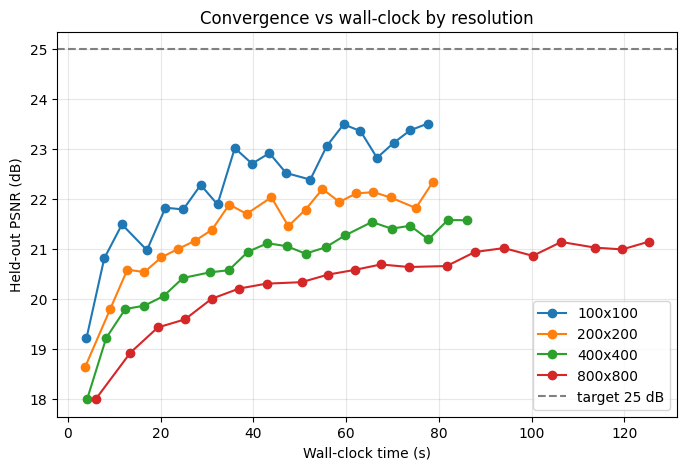

In [7]:
plt.figure(figsize=(8, 5))
for res, curve in curves.items():
    walls = [c[1] for c in curve]
    psnrs = [c[2] for c in curve]
    plt.plot(walls, psnrs, marker="o", label=f"{res}x{res}")
plt.axhline(TARGET_PSNR, ls="--", color="gray", label=f"target {TARGET_PSNR:.0f} dB")
plt.xlabel("Wall-clock time (s)")
plt.ylabel("Held-out PSNR (dB)")
plt.title("Convergence vs wall-clock by resolution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Estimate total compute for the Phase 2 experiment matrix at each resolution.
# Per-run cost is taken as the total wall-clock of one full run at that resolution.
matrix = []
for r in results:
    per_run_s = r["total_run_s"]
    matrix.append({
        "resolution":      r["resolution"],
        "per_run_s":       per_run_s,
        f"matrix_{RUN_COUNT}_runs_h": round(per_run_s * RUN_COUNT / 3600.0, 1),
        "best_psnr_db":    r["best_psnr_db"],
        "peak_vram_mb":    r["peak_vram_mb"],
    })
matrix_df = pd.DataFrame(matrix)
matrix_df

,resolution,per_run_s,matrix_100_runs_h,best_psnr_db,peak_vram_mb
0,100x100,77.6,2.2,23.51,708.6
1,200x200,78.8,2.2,22.35,746.4
2,400x400,86.1,2.4,21.58,900.3
3,800x800,125.3,3.5,21.15,1511.3


# 6. How to read this

- **per_iter_ms** should be roughly flat across resolutions: NeRF training samples a fixed ray batch, so the gradient step does not depend on image size. If it is flat, that confirms resolution is not a per-step cost.
- **total_run_s** and the **matrix estimate** are the decision drivers. They grow with resolution mainly because of evaluation cost and slower convergence, not the training step.
- **best_psnr_db** shows the quality ceiling reached within `N_ITERATIONS`. With the compact TinyNeRF MLP, very high resolutions may plateau lower because the model is capacity-limited; that is itself a useful finding (it would argue for a larger MLP if a high resolution is chosen).
- **peak_vram_mb** confirms the resolution fits comfortably on the RTX 4090.

**Decision rule:** choose the highest resolution whose `matrix_{RUN_COUNT}_runs_h` is within the available compute budget (a few days on the 4090) and whose `best_psnr_db` is acceptable. Record the chosen resolution, iteration budget, and a one-line justification in the Experimental Setup section of `src/nerf_tutorial2.ipynb`.